## 📦 Import All Modules

Add import statements for all available top-level modules

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import numpy as np
import LADPackage
import examples
import shmtools

## Import 3 Story Structure Dataset

LADPackage-compatible version of 3-story structure data import.

In [2]:
# [Dataset, Damage States, List of States] = Import 3 Story Structure Dataset (Floor Numbers)
dataset, damage_states, state_list = LADPackage.utils.import_3story_structure_sub_floors(
    floor_numbers=1  # Floor Numbers (optional)
)

## AR Model

Estimate autoregressive model parameters and compute RMSE.

In [3]:
# [AR Parameters Feature Vectors, RMS Residuals Feature Vectors, AR Prediction] = AR Model (Time Series Data, AR Model Order)
ar_parameters_fv, rms_residuals_fv, ar_prediction = shmtools.ar_model_shm(
    X=dataset,  # Time Series Data (required)
    ar_order=15  # AR Model Order (optional)
)

## Plot Features

Plot feature vectors as subplots for each feature.

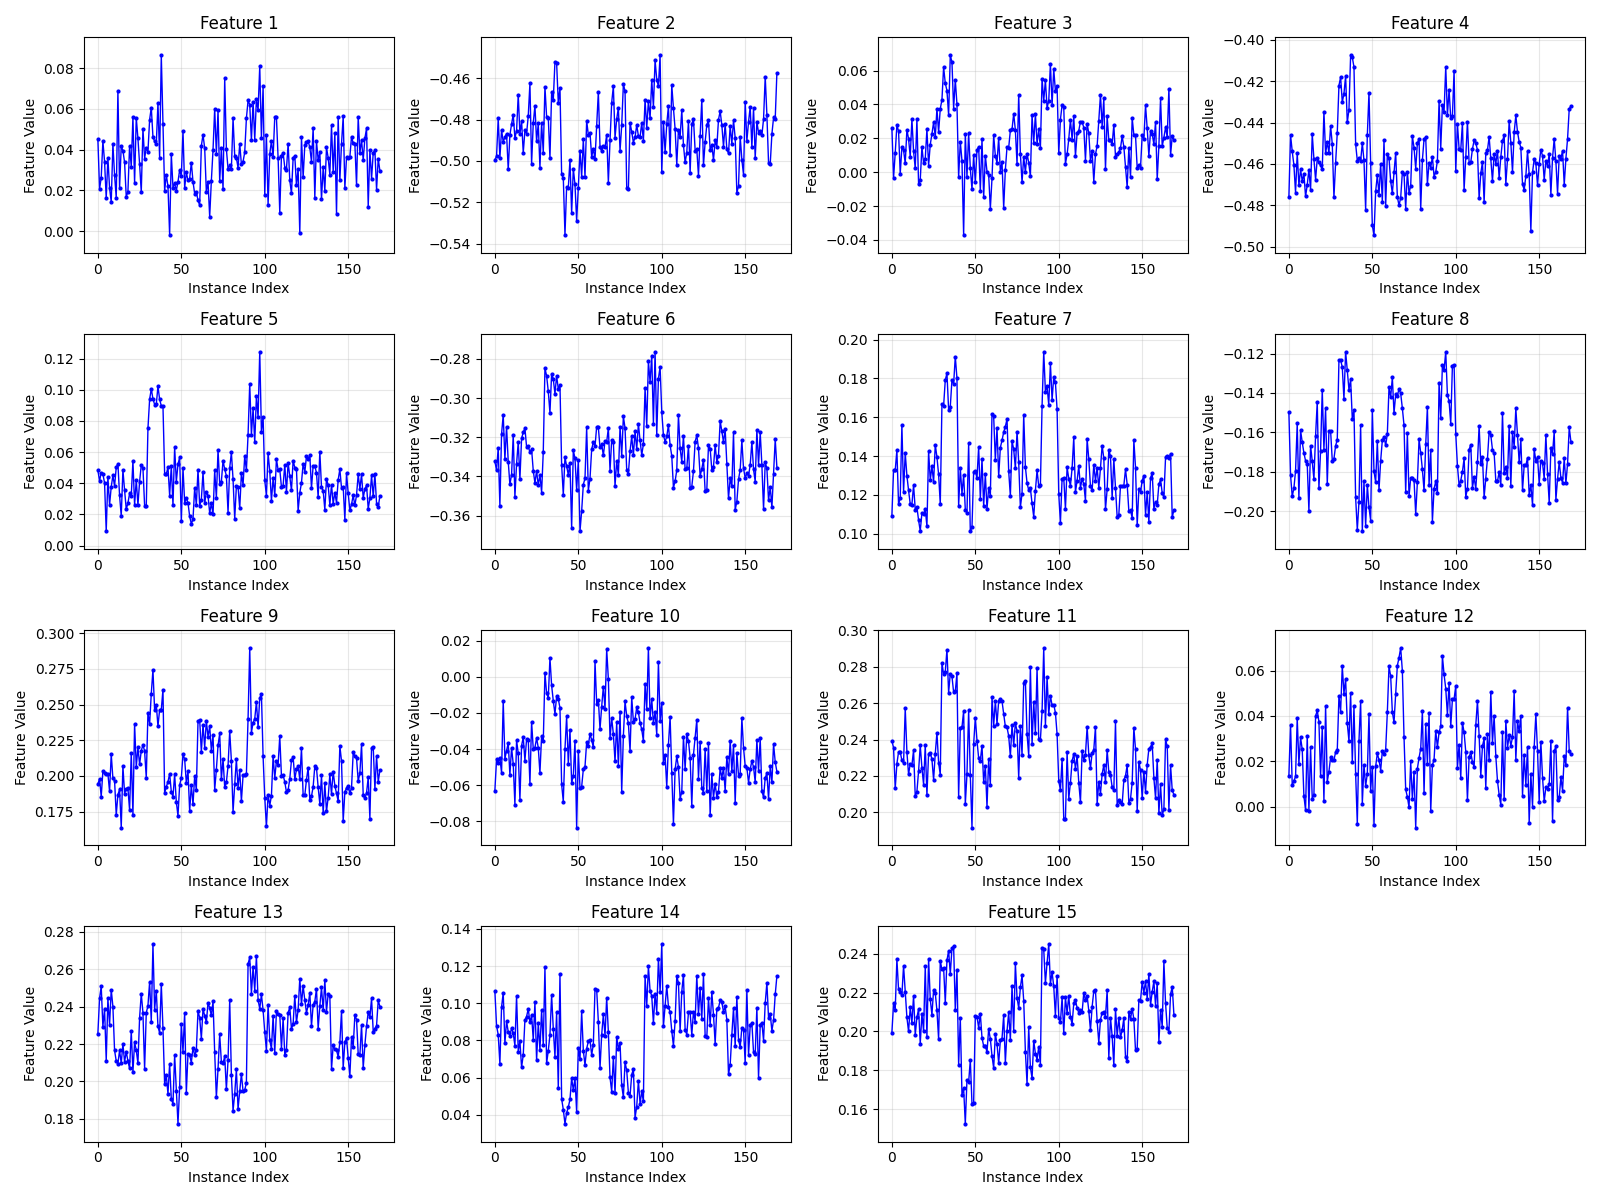

In [4]:
# [Axes Handle] = Plot Features (Feature Vectors, Instances to Plot, Features to Plot, Titles for Subplots, Y-Axis Labels for Subplots, Axes Handle)
axes_handle = shmtools.plotting.plot_features_shm(
    feature_vectors=ar_parameters_fv,  # Feature Vectors (required)
    instance_indices=None,  # Instances to Plot (optional)
    feature_indices=range(0,15),  # Features to Plot (optional)
    subplot_titles=None,  # Titles for Subplots (optional)
    subplot_ylabels=None,  # Y-Axis Labels for Subplots (optional)
    axes_handle=None  # Axes Handle (optional)
)

## Learn Score Mahalanobis

LADPackage wrapper: Split data, train, and score using Mahalanobis distance.

In [5]:
# [Scores] = Learn Score Mahalanobis (Features, Training Indices)
scores = LADPackage.utils.learn_score_mahalanobis(
    features=ar_parameters_fv,  # Features (required)
    training_indices=range(0,91,2)  # Training Indices (required)
)

## Plot Detection Scores

Plot damage detection scores with threshold and classification results.

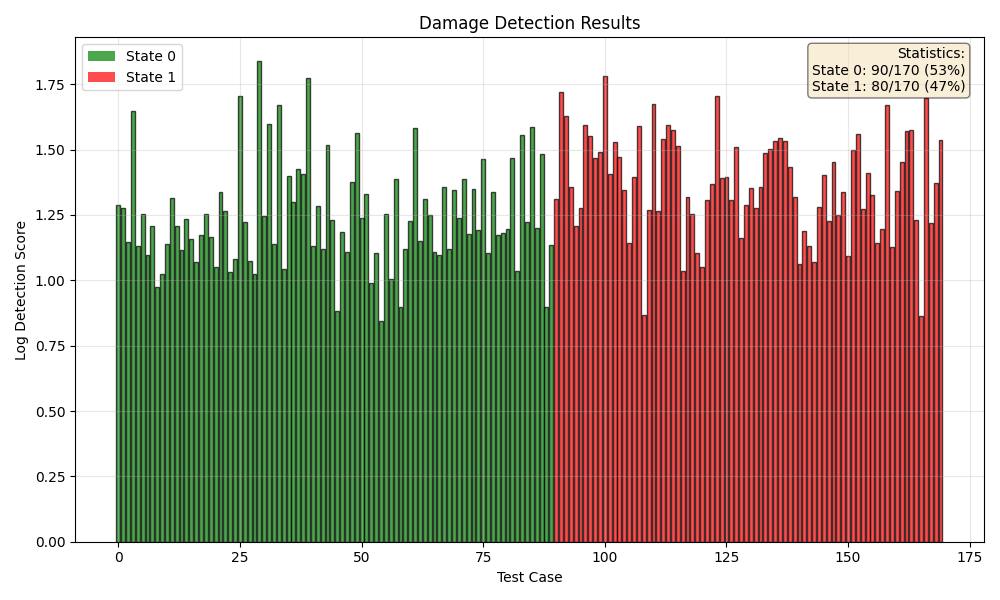

In [6]:
# [Axes Handle] = Plot Detection Scores (Scores, States, State Names, Threshold, Use Bar Chart, Show Legend, Axes Handle)
ax = shmtools.plotting.plot_scores_shm(
    scores=scores,  # Scores (required)
    states=damage_states,  # States (required)
    state_names=None,  # State Names (optional)
    threshold=None,  # Threshold (optional)
    use_bar_chart=True,  # Use Bar Chart (optional)
    show_legend=True,  # Show Legend (optional)
    ax=None,  # Axes Handle (optional)
    flip_signs=True,  # <class 'bool'> (optional)
    use_log_scores=True  # <class 'bool'> (optional)
)

## Plot Score Distributions

Plot distribution of scores using kernel density estimation (KDE).

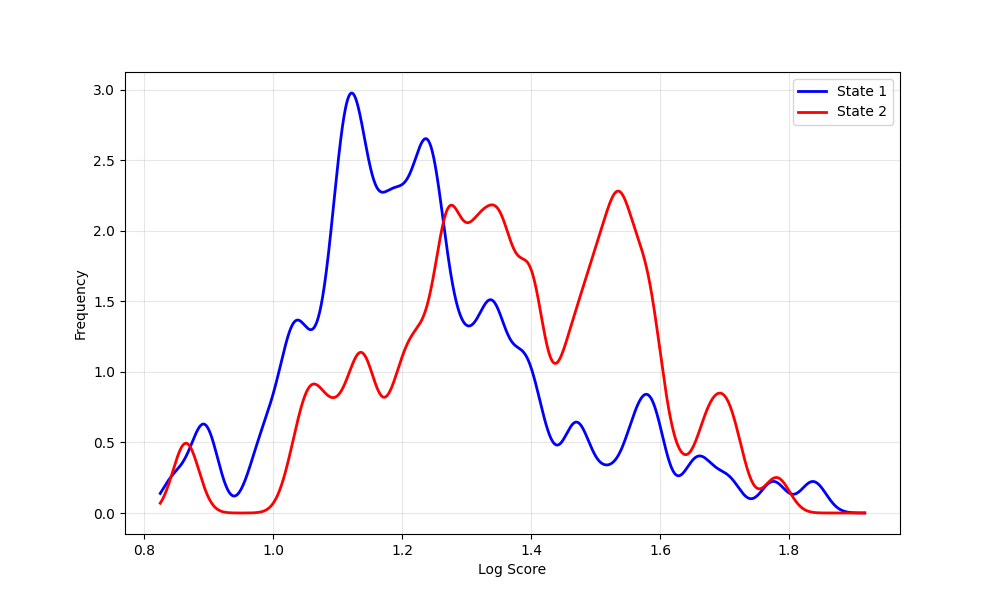

In [7]:
# Axes Handle = Plot Score Distributions (Scores, Damage States, State Names, Thresholds, Flip Signs, Use Log Scores, Kernel Smoothing Parameter, Axes Handle)
axes = shmtools.plotting.plot_score_distributions_shm(
    scores=scores,  # Scores (required)
    states=damage_states,  # Damage States (required)
    state_names=None,  # State Names (optional)
    thresholds=None,  # Thresholds (optional)
    flip_signs=True,  # Flip Signs (optional)
    use_log_scores=True,  # Use Log Scores (optional)
    smoothing=.02,  # Kernel Smoothing Parameter (optional)
    axes=None  # Axes Handle (optional)
)

## ROC Curve

Receiver operating characteristic (ROC) curve.

In [8]:
# [True Positive Rate, False Positive Rate] = ROC Curve (Scores, Damage States, Number of Points, Threshold Type)
TPR, FPR = shmtools.roc_shm(
    scores=scores,  # Scores (required)
    damage_states=damage_states,  # Damage States (required)
    num_pts=None,  # Number of Points (optional)
    threshold_type='below'  # Threshold Type (optional)
)

## ROC Curve Plot

Plot receiver operating characteristic curve.

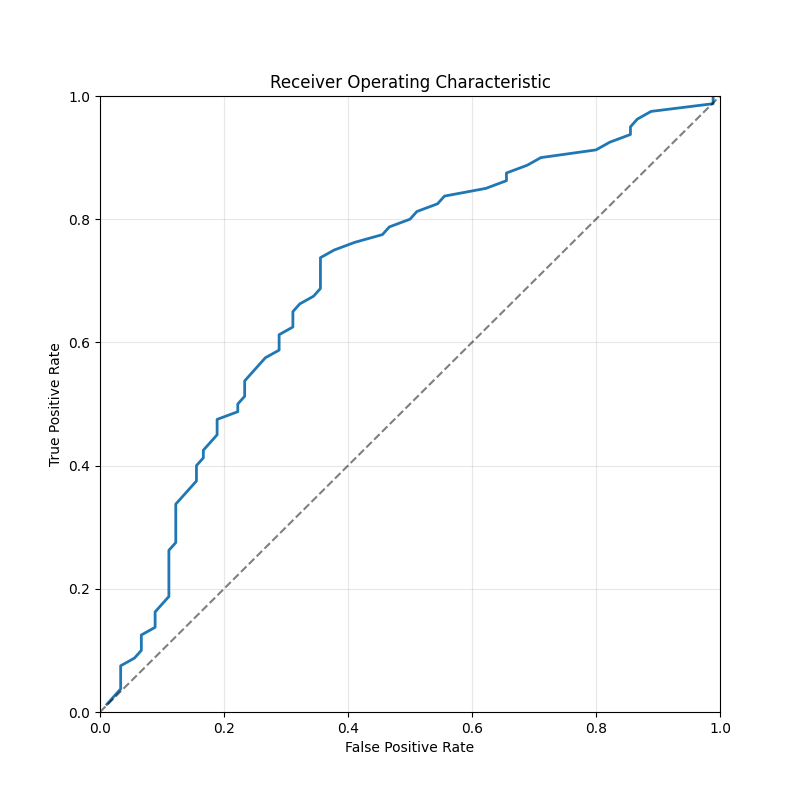

In [9]:
# [Axes Handle] = Plot Receiver Operating Characteristic Curve (True Positive Rate, False Positive Rate, Scaling, Axes Handle)
ax = shmtools.plotting.plot_roc_shm(
    tpr=TPR,  # True Positive Rate (required)
    fpr=FPR,  # False Positive Rate (required)
    scaling='linear',  # Scaling (optional)
    ax=None  # Axes Handle (optional)
)